# Lung Disease Classification v2: proper split, K-fold, ablation
**Dataset:** Multi Lung Disease Dataset (Covid-19, Emphysema, Normal, Pneumonia, Tuberculosis). The 5 class folders are read directly, so no pneumonia merging is needed.

**Run plan (Kaggle 12 h/version limit).** Set `CFG.PHASE` and save a separate version per phase:
| Version | `CFG.PHASE` | What runs |
|---|---|---|
| 1 | `"holdout"` | 70/15/15 split, all models in `MODELS_HOLDOUT` |
| 2 | `"kfold"` | 3-fold CV on the dev pool (train+val), test set untouched |
| 3 | `"ablation"` | ablation of ParallelHybrid |

`"all"` runs everything but stops itself at `BUDGET_HOURS`. Finished runs are stored in `results.json` and skipped on resume (see `RESUME_FROM`).

In [1]:
!pip install -q timm lime grad-cam shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# 1. Imports & config

In [2]:
import os, time, json, random, hashlib, copy, gc, shutil, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm
warnings.filterwarnings("ignore")
NB_START = time.time()

class CFG:
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 4
    PHASE = "kfold"                 # "holdout" | "kfold" | "ablation" | "all"
    # --- epochs per phase ---
    EPOCHS = 15                   # holdout
    KFOLD_EPOCHS = 15             # each fold
    ABL_EPOCHS = 12               # each ablation variant
    PATIENCE = 5                  # early stopping on val macro-F1
    # --- split ---
    TEST_SIZE = 0.15              # held-out test (never used for training/selection)
    VAL_SIZE = 0.15               # of the TOTAL data
    K_FOLDS = 3
    # --- which models ---
    MODELS_HOLDOUT = ["ParallelHybrid"]   # add: "SafeUltraHybrid","ResNet50","DenseNet121","ViT_Base","CrossAttentionHybrid","JointEnsemble","MobileNet_to_ViT"
    MODELS_KFOLD = ["SafeUltraHybrid"]
    # --- misc ---
    BUDGET_HOURS = 11.0           # graceful stop before Kaggle's 12 h
    DEDUP = True                  # drop exact duplicate files / cross-class conflicts
    NORMALIZE = True              # ImageNet mean/std (pretrained backbones expect it)
    USE_AMP = True                # mixed precision (big speedup on T4)
    DATA_ROOT = os.environ.get("DATA_ROOT")   # None -> auto-detect under /kaggle/input

RESUME_FROM = None   # e.g. Path("/kaggle/input/<previous-version-output>") to continue earlier results

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = CFG.USE_AMP and DEVICE == "cuda"
CLASS_NAMES = ["Covid-19", "Emphysema", "Normal", "Pneumonia", "Tuberculosis"]
NUM_CLASSES = len(CLASS_NAMES)
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed(CFG.SEED)

OUT = Path(os.environ.get("OUT_DIR", "/kaggle/working")); OUT.mkdir(parents=True, exist_ok=True)
CACHE = Path("/tmp/cache")
CACHE.mkdir(parents=True, exist_ok=True)
Path("/tmp/ckpt").mkdir(exist_ok=True); (OUT / "probs").mkdir(exist_ok=True)
RESULTS_FILE = OUT / "results.json"

if RESUME_FROM and (Path(RESUME_FROM) / "results.json").exists():
    shutil.copy(Path(RESUME_FROM) / "results.json", RESULTS_FILE)
    for f in (Path(RESUME_FROM) / "probs").glob("*.npy"): shutil.copy(f, OUT / "probs" / f.name)
    print("Resumed results from", RESUME_FROM)
RESULTS = json.load(open(RESULTS_FILE)) if RESULTS_FILE.exists() else {}
print(f"Device: {DEVICE} | AMP: {AMP} | finished runs so far: {len(RESULTS)}")

Device: cuda | AMP: True | finished runs so far: 0


# 2. Data: discover, de-duplicate, split (train / val / test)

In [3]:
def find_root():
    if CFG.DATA_ROOT: return Path(CFG.DATA_ROOT)
    for d, subs, _ in os.walk("/kaggle/input"):
        if set(CLASS_NAMES) <= set(subs): return Path(d)
    raise FileNotFoundError("Class folders not found under /kaggle/input. Set CFG.DATA_ROOT manually.")

ROOT = find_root(); print("Dataset root:", ROOT)
EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
rows = [(str(p), c) for c in CLASS_NAMES for p in sorted((ROOT / c).rglob("*")) if p.suffix.lower() in EXT]
df = pd.DataFrame(rows, columns=["path", "label"])
print("Images found:", len(df))

def md5(p):
    with open(p, "rb") as f: return hashlib.md5(f.read()).hexdigest()

if CFG.DEDUP:
    df["hash"] = Parallel(n_jobs=-1)(delayed(md5)(p) for p in tqdm(df.path, desc="hashing"))
    nl = df.groupby("hash").label.nunique()
    conflict = nl[nl > 1].index
    print(f"exact duplicates: {df.duplicated('hash').sum()} | hashes appearing in >1 class: {len(conflict)}")
    df = df[~df.hash.isin(conflict)].drop_duplicates("hash")
df = df.reset_index(drop=True)
df["y"] = df.label.map(label2idx)
Y_ALL = df.y.values

# ---- stratified 70/15/15 ----
all_idx = np.arange(len(df))
DEV_IDX, TEST_IDX = train_test_split(all_idx, test_size=CFG.TEST_SIZE, stratify=Y_ALL, random_state=CFG.SEED)
TRAIN_IDX, VAL_IDX = train_test_split(DEV_IDX, test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
                                      stratify=Y_ALL[DEV_IDX], random_state=CFG.SEED)
assert not (set(TRAIN_IDX) & set(VAL_IDX)) and not (set(DEV_IDX) & set(TEST_IDX))

split = pd.Series("train", index=all_idx); split[VAL_IDX] = "val"; split[TEST_IDX] = "test"
df["split"] = split.values
print(pd.crosstab(df.label, df.split, margins=True))
df.to_csv(OUT / "splits.csv", index=False)   # reproducibility: cite this in the paper

Dataset root: /kaggle/input/datasets/nobodynub/multi-lung-disease-dataset/Multi Lung Disease Dataset
Images found: 18033


hashing:   0%|          | 0/18033 [00:00<?, ?it/s]

exact duplicates: 45 | hashes appearing in >1 class: 0
split         test  train   val    All
label                                 
Covid-19       449   2096   449   2994
Emphysema      383   1784   383   2550
Normal         491   2288   491   3270
Pneumonia      900   4201   900   6001
Tuberculosis   476   2221   476   3173
All           2699  12590  2699  17988


# 3. Preprocessing cache (CLAHE once, not every epoch) & datasets

In [4]:
def _load(path, size, clahe):
    img = cv2.imread(path)
    if img is None: raise ValueError(f"Corrupted image: {path}")
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if clahe: g = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(g)
    return np.stack([g, g, g], -1)

_CACHE = {}
def get_cache(clahe=True):
    key = bool(clahe)
    if key in _CACHE: return _CACHE[key]
    f = CACHE / f"x_{CFG.IMG_SIZE}_{'clahe' if clahe else 'raw'}_{len(df)}.npy"
    if f.exists(): arr = np.load(f)
    else:
        arr = np.stack(Parallel(n_jobs=-1)(delayed(_load)(p, CFG.IMG_SIZE, clahe) for p in tqdm(df.path, desc=f"cache {'clahe' if clahe else 'raw'}")))
        np.save(f, arr)
    _CACHE[key] = arr; return arr

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

class RandomGamma:
    def __init__(self, r=(0.95, 1.05)): self.r = r
    def __call__(self, img): return T.functional.adjust_gamma(img, random.uniform(*self.r))

def make_tf(aug):
    t = [T.ToPILImage()]
    if aug: t += [T.RandomHorizontalFlip(0.5), T.RandomRotation(7), RandomGamma()]
    t += [T.ToTensor()]
    if CFG.NORMALIZE: t += [T.Normalize(MEAN, STD)]
    return T.Compose(t)

class XrayDS(Dataset):
    def __init__(self, X, idx, tf): self.X, self.idx, self.tf = X, np.asarray(idx), tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]; return self.tf(self.X[j]), int(Y_ALL[j])

def make_loader(X, idx, train, aug=True):
    return DataLoader(XrayDS(X, idx, make_tf(train and aug)), batch_size=CFG.BATCH_SIZE, shuffle=train,
                      drop_last=train, num_workers=CFG.NUM_WORKERS, pin_memory=(DEVICE == "cuda"),
                      persistent_workers=CFG.NUM_WORKERS > 0)

_ = get_cache(True)   # build once up front
print("Cache shape:", _.shape)

cache clahe:   0%|          | 0/17988 [00:00<?, ?it/s]

Cache shape: (17988, 224, 224, 3)


# 4. Models

In [5]:
def r18(p): return models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if p else None)
def mnv2(p): return models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if p else None)

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.fc = nn.Sequential(nn.Conv2d(c, c // 16, 1), nn.ReLU(), nn.Conv2d(c // 16, c, 1))
        self.spatial = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        return x * torch.sigmoid(self.fc(nn.AdaptiveAvgPool2d(1)(x))) * torch.sigmoid(self.spatial(torch.cat([x.mean(1, True), x.max(1, True)[0]], 1)))

class TransformerEncoder(nn.Module):
    def __init__(self, dim, heads, layers):
        super().__init__()
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(dim, heads, batch_first=True), layers)
    def forward(self, x): return self.enc(x)

class ParallelHybrid(nn.Module):
    """ResNet18 stream || ViT-style stream, concatenated. Flags enable ablations."""
    def __init__(self, n_classes, use_cnn=True, use_vit=True, pretrained=True, vit_layers=4, dim=256):
        super().__init__()
        assert use_cnn or use_vit
        self.use_cnn, self.use_vit = use_cnn, use_vit
        if use_cnn: self.cnn_stream = nn.Sequential(*list(r18(pretrained).children())[:-1], nn.Flatten())
        if use_vit:
            self.vit_embed = nn.Conv2d(3, dim, 16, 16)
            self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
            self.pos = nn.Parameter(torch.randn(1, 197, dim) * 0.02)
            self.vit = TransformerEncoder(dim, 4, vit_layers)
        self.head = nn.Linear((512 if use_cnn else 0) + (dim if use_vit else 0), n_classes)
    def forward(self, x):
        f = []
        if self.use_cnn: f.append(self.cnn_stream(x))
        if self.use_vit:
            v = self.vit_embed(x).flatten(2).transpose(1, 2)
            v = torch.cat([self.cls_token.expand(x.size(0), -1, -1), v], 1) + self.pos
            f.append(self.vit(v)[:, 0])
        return self.head(torch.cat(f, 1))

class CrossAttentionHybrid(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super().__init__()
        self.backbone = nn.Sequential(*list(r18(pretrained).children())[:-2])
        self.proj = nn.Conv2d(512, 256, 1)
        self.query = nn.Parameter(torch.randn(1, 1, 256))
        self.attn = nn.MultiheadAttention(256, 4, batch_first=True)
        self.norm = nn.LayerNorm(256); self.dropout = nn.Dropout(0.1); self.fc = nn.Linear(256, n_classes)
    def forward(self, x):
        k = self.proj(self.backbone(x)).flatten(2).transpose(1, 2)
        q = self.query.expand(x.size(0), -1, -1)
        res, _ = self.attn(q, k, k)
        res = self.dropout(self.norm(res + q))
        return self.fc(res.squeeze(1))

class JointEnsemble(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super().__init__()
        self.m1 = mnv2(pretrained); self.m1.classifier[1] = nn.Linear(1280, n_classes)
        self.vit_embed = nn.Conv2d(3, 256, 16, 16); self.vit = TransformerEncoder(256, 4, 4)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 256)); self.head2 = nn.Linear(256, n_classes)
    def forward(self, x):
        v = self.vit_embed(x).flatten(2).transpose(1, 2)
        v = self.vit(torch.cat([self.cls_token.expand(x.size(0), -1, -1), v], 1))
        return (self.m1(x) + self.head2(v[:, 0])) / 2

class MobileNet_to_ViT(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super().__init__()
        self.feats = mnv2(pretrained).features
        self.proj = nn.Conv2d(1280, 256, 1); self.vit = TransformerEncoder(256, 4, 4)
        self.head = nn.Linear(256, n_classes); self.cls_token = nn.Parameter(torch.randn(1, 1, 256))
    def forward(self, x):
        x = self.proj(self.feats(x)).flatten(2).transpose(1, 2)
        x = torch.cat((self.cls_token.expand(x.size(0), -1, -1), x), 1)
        return self.head(self.vit(x)[:, 0])

class SafeUltraHybrid(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=pretrained, features_only=True)
        self.cbam = CBAM(384); self.pool = nn.AdaptiveAvgPool2d(1)
        self.vit_embed = nn.Conv2d(3, 256, 16, 16)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 256)); self.pos = nn.Parameter(torch.randn(1, 197, 256))
        self.pre_norm = nn.LayerNorm(256); self.vit = TransformerEncoder(256, 8, 4); self.post_norm = nn.LayerNorm(256)
        self.proj_cnn = nn.Sequential(nn.Linear(384, 512), nn.LayerNorm(512), nn.SiLU(inplace=True), nn.Dropout(0.2))
        self.proj_vit = nn.Sequential(nn.Linear(256, 512), nn.LayerNorm(512), nn.SiLU(inplace=True), nn.Dropout(0.2))
        self.fusion = nn.Sequential(nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.SiLU(inplace=True), nn.Dropout(0.25),
                                    nn.Linear(512, 256), nn.SiLU(inplace=True), nn.Dropout(0.15))
        self.head = nn.Linear(256, n_classes)
    def forward(self, x):
        c = self.proj_cnn(self.pool(self.cbam(self.backbone(x)[-1])).flatten(1))
        v = self.vit_embed(x).flatten(2).transpose(1, 2)
        v = torch.cat([self.cls_token.expand(x.size(0), -1, -1), v], 1) + self.pos
        v = self.proj_vit(self.post_norm(self.vit(self.pre_norm(v))[:, 0]))
        return self.head(self.fusion(torch.cat([c, v], 1)))

def ResNet50_Baseline(n, pretrained=True):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
    m.fc = nn.Linear(m.fc.in_features, n); return m
def DenseNet121_Baseline(n, pretrained=True):
    m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)
    m.classifier = nn.Linear(m.classifier.in_features, n); return m
def ViT_Base_Baseline(n, pretrained=True):
    return timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=n)

MODEL_BUILDERS = {
    "ParallelHybrid": lambda **k: ParallelHybrid(NUM_CLASSES, **k),
    "CrossAttentionHybrid": lambda **k: CrossAttentionHybrid(NUM_CLASSES, **k),
    "JointEnsemble": lambda **k: JointEnsemble(NUM_CLASSES, **k),
    "MobileNet_to_ViT": lambda **k: MobileNet_to_ViT(NUM_CLASSES, **k),
    "SafeUltraHybrid": lambda **k: SafeUltraHybrid(NUM_CLASSES, **k),
    "ResNet50": lambda **k: ResNet50_Baseline(NUM_CLASSES, **k),
    "DenseNet121": lambda **k: DenseNet121_Baseline(NUM_CLASSES, **k),
    "ViT_Base": lambda **k: ViT_Base_Baseline(NUM_CLASSES, **k),
}
MODEL_LR = {"ParallelHybrid": 1.5e-4, "CrossAttentionHybrid": 1.2e-4, "JointEnsemble": 1e-4, "MobileNet_to_ViT": 1.3e-4,
            "SafeUltraHybrid": 1.2e-4, "ResNet50": 2e-4, "DenseNet121": 1.8e-4, "ViT_Base": 8e-5}

DISPLAY = {
    "ParallelHybrid":       "Parallel CNN–Transformer Network (PCT-Net)",
    "CrossAttentionHybrid": "Cross-Attention CNN–Transformer (CA-CT)",
    "JointEnsemble":        "Late-Fusion MobileNetV2–ViT Ensemble (LF-MViT)",
    "MobileNet_to_ViT":     "Sequential MobileNetV2–ViT (MNV2-ViT)",
    "SafeUltraHybrid":      "EfficientNet-B3–CBAM–Transformer (EB3-CBAM-T)",
    "ResNet50":             "ResNet-50",
    "DenseNet121":          "DenseNet-121",
    "ViT_Base":             "ViT-Base/16",
}

def build_model(name, kw=None): return MODEL_BUILDERS[name](**(kw or {}))

# 5. Losses

In [6]:
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma_neg=2.5, gamma_pos=1.0, eps=1e-8, class_weights=None):
        super().__init__()
        self.gn, self.gp, self.eps, self.cw = gamma_neg, gamma_pos, eps, class_weights
    def forward(self, logits, targets):
        p = torch.softmax(logits.float(), 1)
        oh = F.one_hot(targets, logits.size(1)).float()
        pos = oh * torch.log(p + self.eps) * ((1 - p) ** self.gp)
        neg = (1 - oh) * torch.log(1 - p + self.eps) * (p ** self.gn)
        loss = -(pos + neg)
        if self.cw is not None: loss = loss * self.cw.unsqueeze(0)
        return loss.mean()

def build_loss(kind, cw):
    if kind == "ce": return nn.CrossEntropyLoss(weight=cw)
    if kind == "asym_focal": return AsymmetricFocalLoss(class_weights=cw)
    raise ValueError(kind)

# 6. Training engine (AMP, best-checkpoint by macro-F1, early stopping, time guard, resumable)

In [7]:
DEADLINE = NB_START + CFG.BUDGET_HOURS * 3600
def time_left(): return DEADLINE - time.time()
EPOCH_SEC = None
_printed_proj = False

def planned_epochs():
    n = 0
    if CFG.PHASE in ("all", "holdout"): n += len(CFG.MODELS_HOLDOUT) * CFG.EPOCHS
    if CFG.PHASE in ("all", "kfold"): n += len(CFG.MODELS_KFOLD) * CFG.K_FOLDS * CFG.KFOLD_EPOCHS
    if CFG.PHASE in ("all", "ablation"): n += 10 * CFG.ABL_EPOCHS   # 10 ablation variants
    return n

@torch.no_grad()
def get_logits(model, loader, tta=False):
    model.eval(); out = []
    for x, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=AMP):
            lg = model(x)
            if tta: lg = (lg + model(torch.flip(x, dims=[3]))) / 2
        out.append(lg.float().cpu())
    return torch.cat(out)

def metrics(logits_or_probs, y):
    pred = logits_or_probs.argmax(1) if hasattr(logits_or_probs, "argmax") else np.argmax(logits_or_probs, 1)
    pred = np.asarray(pred)
    return dict(acc=float((pred == y).mean()), macro_f1=float(f1_score(y, pred, average="macro")),
                weighted_f1=float(f1_score(y, pred, average="weighted")),
                report=classification_report(y, pred, target_names=CLASS_NAMES, digits=4, zero_division=0),
                cm=confusion_matrix(y, pred, labels=range(NUM_CLASSES)).tolist())

def train_one(tag, spec, tr_idx, va_idx, epochs):
    global EPOCH_SEC, _printed_proj
    X = get_cache(spec["clahe"])
    tr_ld, va_ld = make_loader(X, tr_idx, True, spec["aug"]), make_loader(X, va_idx, False)
    yva = Y_ALL[va_idx]
    model = build_model(spec["model"], spec.get("model_kwargs")).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    cw = None
    if spec["class_weights"]:
        cw = torch.tensor(compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=Y_ALL[tr_idx]), dtype=torch.float, device=DEVICE)
    crit = build_loss(spec["loss"], cw)
    opt = torch.optim.AdamW(model.parameters(), lr=spec.get("lr") or MODEL_LR[spec["model"]], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)
    hist = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_f1=[])
    best_f1, best_ep, best_state, bad, cut_by_time = -1, -1, None, 0, False
    print(f"\n=== {tag} | {spec['model']} | {n_params:.1f}M params | train {len(tr_idx)} / val {len(va_idx)} ===")
    t_run = time.time()
    for ep in range(epochs):
        t0 = time.time(); model.train(); tl, corr, n = 0.0, 0, 0
        for x, y in tqdm(tr_ld, desc=f"ep {ep+1}/{epochs}", leave=False):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=AMP):
                lg = model(x)
            loss = crit(lg.float(), y)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            tl += loss.item(); corr += (lg.argmax(1) == y).sum().item(); n += y.size(0)
        sched.step()
        vl = get_logits(model, va_ld)
        vloss = float(crit(vl, torch.tensor(yva))) if cw is None else float(build_loss(spec["loss"], cw.cpu())(vl, torch.tensor(yva)))
        m = metrics(vl, yva)
        hist["train_loss"].append(tl / len(tr_ld)); hist["val_loss"].append(vloss)
        hist["train_acc"].append(100 * corr / n); hist["val_acc"].append(100 * m["acc"]); hist["val_f1"].append(m["macro_f1"])
        dt = time.time() - t0
        EPOCH_SEC = dt if EPOCH_SEC is None else 0.7 * EPOCH_SEC + 0.3 * dt
        if not _printed_proj:
            _printed_proj = True
            print(f"  first epoch {dt/60:.1f} min -> rough projection for planned phase: {planned_epochs()*dt/3600:.1f} h (heavier models take longer)")
        print(f"  ep {ep+1:02d} | loss {hist['train_loss'][-1]:.4f}/{vloss:.4f} | acc {hist['train_acc'][-1]:.2f}/{100*m['acc']:.2f} | val F1 {m['macro_f1']:.4f} | {dt/60:.1f} min")
        if m["macro_f1"] > best_f1:
            best_f1, best_ep, bad = m["macro_f1"], ep + 1, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG.PATIENCE: print("  early stop"); break
        if time_left() < 1.5 * EPOCH_SEC + 300:
            print("  ⏱ time budget reached, stopping this run early"); cut_by_time = True; break
    model.load_state_dict(best_state)
    ck = Path("/tmp/ckpt") / (tag.replace("/", "__") + ".pt"); torch.save(best_state, ck)
    info = dict(history=hist, best_epoch=best_ep, best_val_f1=best_f1, epochs_run=len(hist["train_loss"]),
                params_m=n_params, minutes=(time.time() - t_run) / 60, cut_by_time=cut_by_time, ckpt=str(ck))
    return model, info

def run_experiment(tag, spec, tr_idx, va_idx, epochs):
    if tag in RESULTS: print(f"↩ {tag}: already done, skipping"); return RESULTS[tag]
    if EPOCH_SEC and time_left() < EPOCH_SEC * epochs * 1.15 + 300:
        print(f"⏭ {tag}: not enough time left in this version, will resume next version"); return None
    model, info = train_one(tag, spec, tr_idx, va_idx, epochs)
    if info["cut_by_time"]:   # truncated run is not comparable -> discard, redo in next version
        print(f"  ⚠ {tag} cut by time budget, NOT saved; it will rerun next version")
        del model; gc.collect(); torch.cuda.empty_cache(); return None
    Xt = get_cache(spec["clahe"]); te_ld = make_loader(Xt, TEST_IDX, False); yt = Y_ALL[TEST_IDX]
    lg = get_logits(model, te_ld, tta=True)
    test = metrics(lg, yt); test_no_tta = metrics(get_logits(model, te_ld, tta=False), yt)
    np.save(OUT / "probs" / (tag.replace("/", "__") + ".npy"), torch.softmax(lg, 1).numpy())
    val = metrics(get_logits(model, make_loader(Xt, va_idx, False)), Y_ALL[va_idx])
    res = dict(spec=spec, **info, val=dict(acc=val["acc"], macro_f1=val["macro_f1"]), test=test,
               test_noTTA=dict(acc=test_no_tta["acc"], macro_f1=test_no_tta["macro_f1"]))
    RESULTS[tag] = res; json.dump(RESULTS, open(RESULTS_FILE, "w"), default=str)
    print(f"  ✅ TEST (TTA): acc {test['acc']:.4f} | macro-F1 {test['macro_f1']:.4f}")
    del model; gc.collect(); torch.cuda.empty_cache()
    return res

def base_spec(name): return dict(model=name, model_kwargs={}, loss="asym_focal", class_weights=True, aug=True, clahe=True)
print("Planned epochs for this PHASE:", planned_epochs())

Planned epochs for this PHASE: 45


# 7. Phase A: hold-out (train / val / test)

In [8]:
if CFG.PHASE in ("all", "holdout"):
    for name in CFG.MODELS_HOLDOUT:
        run_experiment(f"holdout/{name}", base_spec(name), TRAIN_IDX, VAL_IDX, CFG.EPOCHS)

# 8. Phase B: stratified K-fold
Folds are cut from the **dev pool (train+val)**; the 15 % test set is never touched. Each fold model is scored on its own validation fold *and* on the same test set; the fold models are also soft-vote ensembled on test.

In [9]:
skf = StratifiedKFold(n_splits=CFG.K_FOLDS, shuffle=True, random_state=CFG.SEED)
FOLDS = [(DEV_IDX[a], DEV_IDX[b]) for a, b in skf.split(DEV_IDX, Y_ALL[DEV_IDX])]
if CFG.PHASE in ("all", "kfold"):
    for name in CFG.MODELS_KFOLD:
        for f, (tr, va) in enumerate(FOLDS):
            run_experiment(f"kfold/{name}/fold{f}", base_spec(name), tr, va, CFG.KFOLD_EPOCHS)

def summarize_kfold(name):
    keys = [k for k in RESULTS if k.startswith(f"kfold/{name}/fold")]
    if not keys: return None
    r = [RESULTS[k] for k in keys]
    tab = pd.DataFrame({"fold": [k.split("/")[-1] for k in keys], "val_acc": [x["val"]["acc"] for x in r],
                        "val_macroF1": [x["val"]["macro_f1"] for x in r], "test_acc": [x["test"]["acc"] for x in r],
                        "test_macroF1": [x["test"]["macro_f1"] for x in r]})
    print(f"\n{DISPLAY[name]}: {len(keys)}/{CFG.K_FOLDS} folds done"); display(tab.round(4))
    print(tab.drop(columns="fold").agg(["mean", "std"]).round(4))
    P = np.mean([np.load(OUT / "probs" / (k.replace("/", "__") + ".npy")) for k in keys], 0)
    ens = metrics(P, Y_ALL[TEST_IDX])
    print(f"Fold-ensemble on test: acc {ens['acc']:.4f} | macro-F1 {ens['macro_f1']:.4f}")
    return tab

for name in CFG.MODELS_KFOLD: summarize_kfold(name)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



=== kfold/SafeUltraHybrid/fold0 | SafeUltraHybrid | 16.6M params | train 10192 / val 5097 ===


ep 1/15:   0%|          | 0/318 [00:00<?, ?it/s]

  first epoch 1.5 min -> rough projection for planned phase: 1.1 h (heavier models take longer)
  ep 01 | loss 0.0601/0.0246 | acc 86.74/94.53 | val F1 0.9427 | 1.5 min


...

  ep 14 | loss 0.0011/nan | acc 99.72/98.16 | val F1 0.9792 | 1.3 min


ep 15/15:   0%|          | 0/318 [00:00<?, ?it/s]

  ep 15 | loss 0.0010/nan | acc 99.76/98.16 | val F1 0.9792 | 1.3 min
  ✅ TEST (TTA): acc 0.9822 | macro-F1 0.9809

EfficientNet-B3–CBAM–Transformer (EB3-CBAM-T): 3/3 folds done


,fold,val_acc,val_macroF1,test_acc,test_macroF1
0,fold0,0.9816,0.9798,0.9796,0.9774
1,fold1,0.9782,0.9776,0.9796,0.9789
2,fold2,0.9816,0.9792,0.9822,0.9809


      val_acc  val_macroF1  test_acc  test_macroF1
mean   0.9804       0.9789    0.9805        0.9791
std    0.0019       0.0012    0.0015        0.0018
Fold-ensemble on test: acc 0.9856 | macro-F1 0.9849


# 9. Phase C: ablation study (ParallelHybrid)
Every variant changes **one** thing vs. `A0_full`, uses the same split, seed, and `ABL_EPOCHS`. `A0_full` is re-run at `ABL_EPOCHS` so comparisons are fair. The no-TTA ablation is free: it is evaluated on every run (`test_noTTA`).

In [10]:
def variant(**over):
    s = copy.deepcopy(base_spec("ParallelHybrid"))
    for k, v in over.items():
        if k == "model_kwargs": s["model_kwargs"].update(v)
        else: s[k] = v
    return s

ABLATIONS = {
    "A0_full":            variant(),
    "A1_cnn_only":        variant(model_kwargs=dict(use_vit=False)),
    "A2_vit_only":        variant(model_kwargs=dict(use_cnn=False)),
    "A3_no_pretrain":     variant(model_kwargs=dict(pretrained=False)),
    "A4_shallow_vit_2L":  variant(model_kwargs=dict(vit_layers=2)),
    "A5_no_CLAHE":        variant(clahe=False),
    "A6_no_augmentation": variant(aug=False),
    "A7_CE_loss":         variant(loss="ce", class_weights=False),
    "A8_weighted_CE":     variant(loss="ce", class_weights=True),
    "A9_asym_no_cw":      variant(class_weights=False),
}
if CFG.PHASE in ("all", "ablation"):
    for name, spec in ABLATIONS.items():
        run_experiment(f"ablation/{name}", spec, TRAIN_IDX, VAL_IDX, CFG.ABL_EPOCHS)

# 10. Summary tables

In [11]:
def table(prefix):
    rows = []
    for k, r in RESULTS.items():
        if k.startswith(prefix):
            rows.append({"run": k.split("/", 1)[1], "params_M": round(r["params_m"], 1), "best_ep": r["best_epoch"], "min": round(r["minutes"], 1),
                         "val_F1": r["val"]["macro_f1"], "test_acc": r["test"]["acc"], "test_F1": r["test"]["macro_f1"],
                         "test_F1_noTTA": r["test_noTTA"]["macro_f1"]})
    return pd.DataFrame(rows)

h = table("holdout/")
if len(h): print("HOLD-OUT"); display(h.round(4))
a = table("ablation/")
if len(a):
    ref = a.loc[a.run == "A0_full", "test_F1"]
    if len(ref): a["ΔF1_vs_full"] = a.test_F1 - float(ref.iloc[0])
    print("ABLATION (test set)"); display(a.round(4))
    a.to_csv(OUT / "ablation_table.csv", index=False)
if len(h): h.to_csv(OUT / "holdout_table.csv", index=False)

In [12]:
def kfold_paper_table():
    rows = []
    for name in MODEL_BUILDERS:
        ks = [k for k in RESULTS if k.startswith(f"kfold/{name}/fold")]
        if not ks: continue
        r = [RESULTS[k] for k in ks]
        g = lambda a, b: np.array([x[a][b] for x in r])
        ms = lambda v: f"{100*v.mean():.2f} ± {(100*v.std(ddof=1) if len(v) > 1 else 0):.2f}"
        rows.append({"Model": DISPLAY[name], "Params (M)": round(r[0]["params_m"], 2), "Folds": len(ks),
                     "Val Acc (%)": ms(g("val", "acc")), "Test Acc (%)": ms(g("test", "acc")),
                     "Test Macro-F1 (%)": ms(g("test", "macro_f1"))})
    t = pd.DataFrame(rows); display(t); t.to_csv(OUT / "kfold_table.csv", index=False); return t
kfold_paper_table()

,Model,Params (M),Folds,Val Acc (%),Test Acc (%),Test Macro-F1 (%)
0,EfficientNet-B3–CBAM–Transformer (EB3-CBAM-T),16.62,3,98.04 ± 0.19,98.05 ± 0.15,97.91 ± 0.18


,Model,Params (M),Folds,Val Acc (%),Test Acc (%),Test Macro-F1 (%)
0,EfficientNet-B3–CBAM–Transformer (EB3-CBAM-T),16.62,3,98.04 ± 0.19,98.05 ± 0.15,97.91 ± 0.18


# 11. Curves & confusion matrices

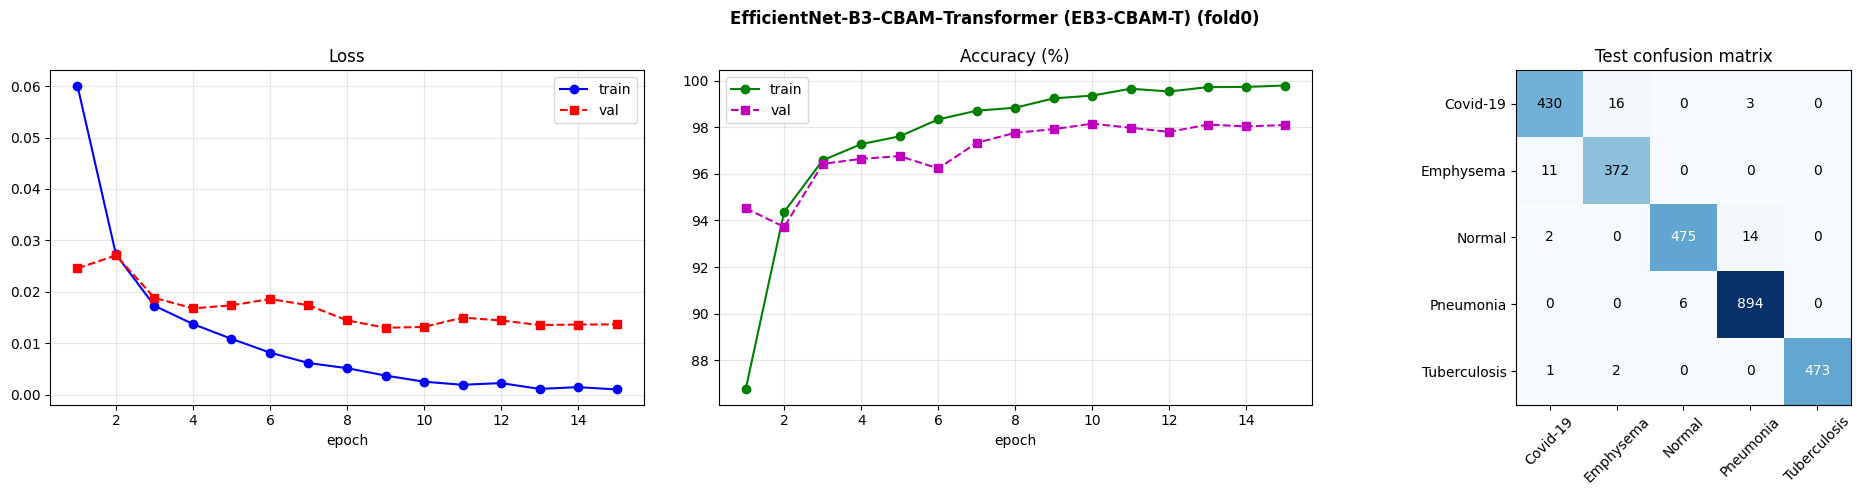

              precision    recall  f1-score   support

    Covid-19     0.9685    0.9577    0.9630       449
   Emphysema     0.9538    0.9713    0.9625       383
      Normal     0.9875    0.9674    0.9774       491
   Pneumonia     0.9813    0.9933    0.9873       900
Tuberculosis     1.0000    0.9937    0.9968       476

    accuracy                         0.9796      2699
   macro avg     0.9782    0.9767    0.9774      2699
weighted avg     0.9797    0.9796    0.9796      2699



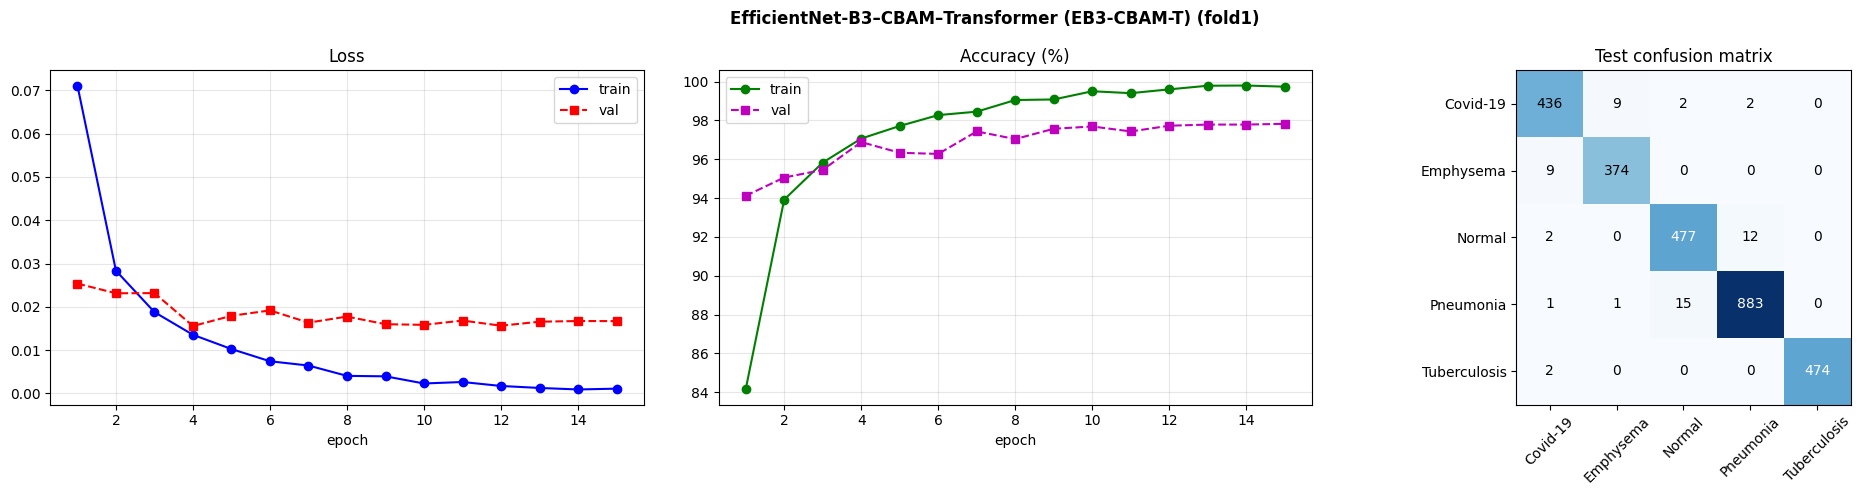

              precision    recall  f1-score   support

    Covid-19     0.9689    0.9710    0.9700       449
   Emphysema     0.9740    0.9765    0.9752       383
      Normal     0.9656    0.9715    0.9685       491
   Pneumonia     0.9844    0.9811    0.9827       900
Tuberculosis     1.0000    0.9958    0.9979       476

    accuracy                         0.9796      2699
   macro avg     0.9786    0.9792    0.9789      2699
weighted avg     0.9797    0.9796    0.9796      2699



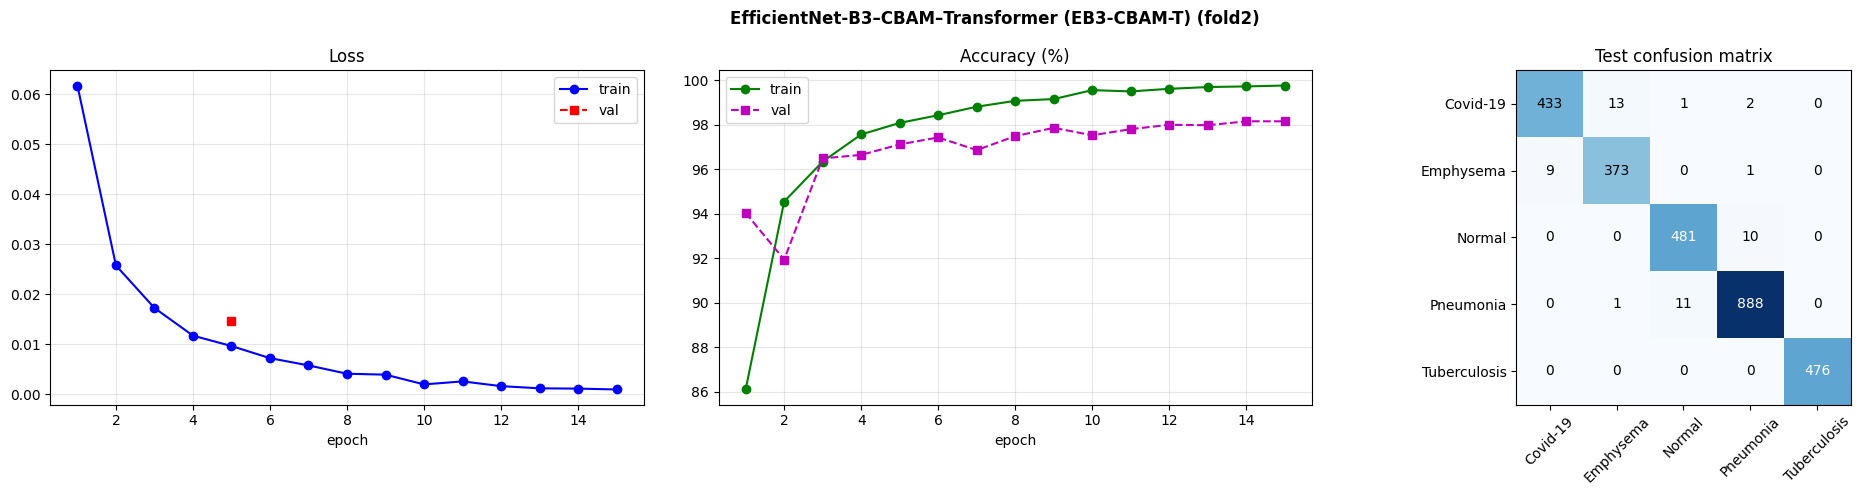

              precision    recall  f1-score   support

    Covid-19     0.9796    0.9644    0.9719       449
   Emphysema     0.9638    0.9739    0.9688       383
      Normal     0.9757    0.9796    0.9776       491
   Pneumonia     0.9856    0.9867    0.9861       900
Tuberculosis     1.0000    1.0000    1.0000       476

    accuracy                         0.9822      2699
   macro avg     0.9809    0.9809    0.9809      2699
weighted avg     0.9822    0.9822    0.9822      2699



In [13]:
def plot_run(tag):
    r = RESULTS[tag]; hst = r["history"]; ep = range(1, len(hst["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(20, 5)); fig.suptitle(f"{DISPLAY[tag.split('/')[1]]} ({tag.split('/')[-1]})", fontweight="bold")
    ax[0].plot(ep, hst["train_loss"], "b-o", label="train"); ax[0].plot(ep, hst["val_loss"], "r--s", label="val"); ax[0].set_title("Loss")
    ax[1].plot(ep, hst["train_acc"], "g-o", label="train"); ax[1].plot(ep, hst["val_acc"], "m--s", label="val"); ax[1].set_title("Accuracy (%)")
    cm = np.array(r["test"]["cm"]); ax[2].imshow(cm, cmap="Blues"); ax[2].set_title("Test confusion matrix")
    ax[2].set_xticks(range(NUM_CLASSES)); ax[2].set_xticklabels(CLASS_NAMES, rotation=45); ax[2].set_yticks(range(NUM_CLASSES)); ax[2].set_yticklabels(CLASS_NAMES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES): ax[2].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    for a_ in ax[:2]: a_.legend(); a_.grid(alpha=.3); a_.set_xlabel("epoch")
    plt.tight_layout(); plt.savefig(OUT / (tag.replace("/", "__") + ".png"), dpi=200); plt.show()
    print(r["test"]["report"])

for k in RESULTS:
    if k.startswith(("holdout/", "kfold/")): plot_run(k)

# 12. Explainability (LIME, SHAP, Grad-CAM++) on the saved best checkpoint

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:40, 40.24s/it]               


Grad-CAM++ failed: BaseCAM.__call__() missing 1 required positional argument: 'targets'


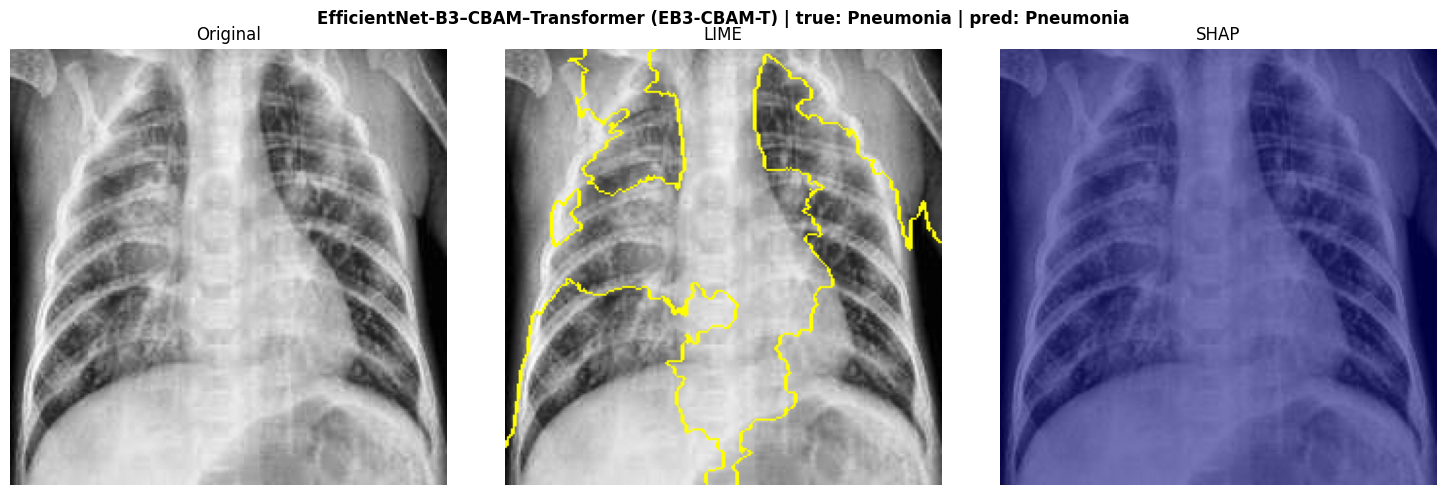

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:16, 16.47s/it]               


Grad-CAM++ failed: BaseCAM.__call__() missing 1 required positional argument: 'targets'


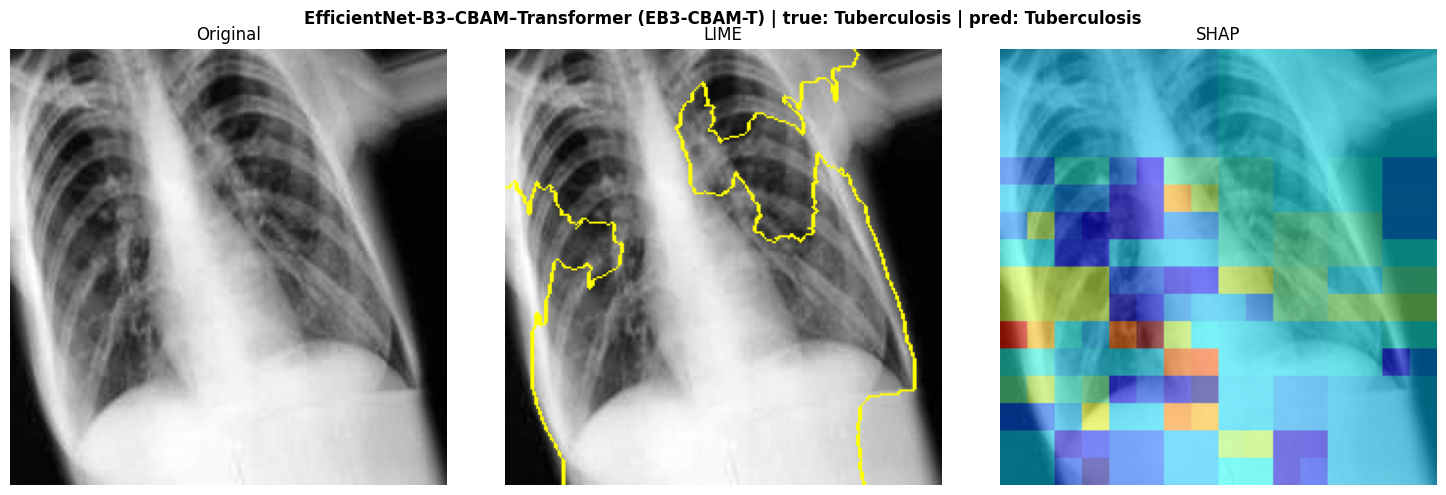

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:15, 15.14s/it]               


Grad-CAM++ failed: BaseCAM.__call__() missing 1 required positional argument: 'targets'


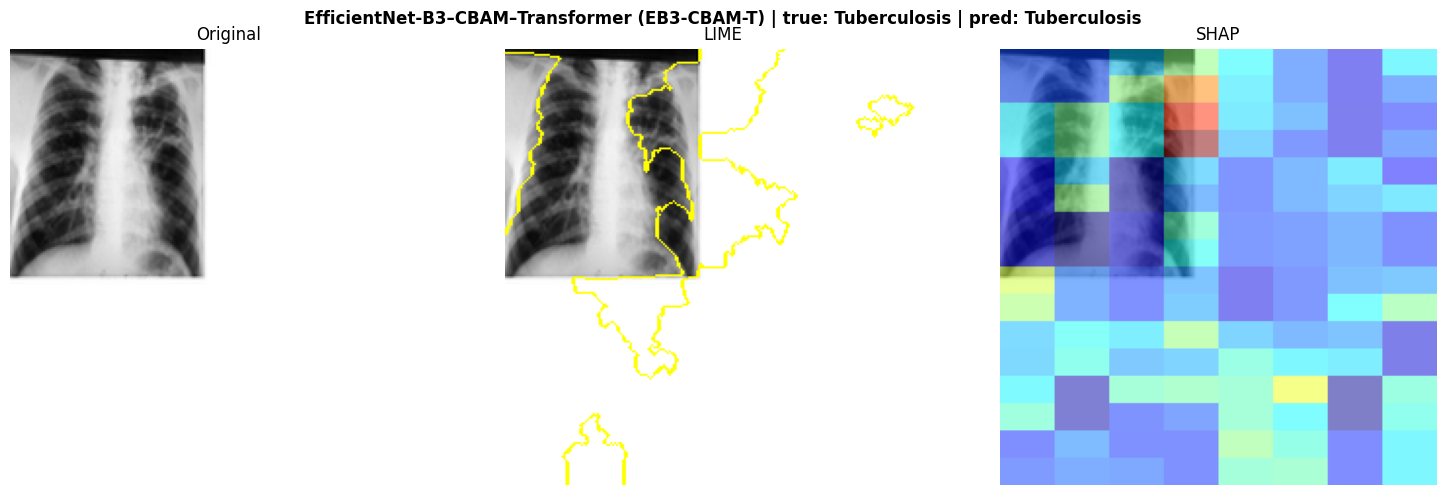

In [14]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

XAI_LAYER = {"ParallelHybrid": lambda m: m.cnn_stream[7], "CrossAttentionHybrid": lambda m: m.backbone[7],
             "JointEnsemble": lambda m: m.m1.features[-1], "MobileNet_to_ViT": lambda m: m.feats[-1],
             "SafeUltraHybrid": lambda m: m.cbam, "ResNet50": lambda m: m.layer4[-1],
             "DenseNet121": lambda m: m.features[-1], "ViT_Base": lambda m: m.blocks[-1].norm1}

def vit_reshape(t):                       # B,197,768 -> B,768,14,14 (ViT_Base only)
    return t[:, 1:, :].reshape(t.size(0), 14, 14, t.size(2)).permute(0, 3, 1, 2)

def best_ckpt(name):                      # best fold (by val F1) trained in THIS version
    ks = [k for k in RESULTS if k.startswith((f"holdout/{name}", f"kfold/{name}/fold"))
          and Path(RESULTS[k]["ckpt"]).exists()]
    return RESULTS[max(ks, key=lambda k: RESULTS[k]["best_val_f1"])]["ckpt"] if ks else None

def explain(name, sample_pos, ckpt, lime_samples=1000, shap_evals=500):
    model = build_model(name).to(DEVICE); model.load_state_dict(torch.load(ckpt, map_location=DEVICE)); model.eval()
    mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1); std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
    def prep(x01):
        t = torch.from_numpy(np.asarray(x01)).float().permute(0, 3, 1, 2).to(DEVICE)
        return (t - mean) / std if CFG.NORMALIZE else t
    def predict01(x01):
        with torch.no_grad(): return torch.softmax(model(prep(x01)), 1).cpu().numpy()
    j = TEST_IDX[sample_pos]; img_u8 = get_cache(True)[j]; img01 = img_u8.astype(np.float32) / 255
    pred = int(predict01(img01[None]).argmax()); vis = [("Original", img01)]
    try:
        ex = lime_image.LimeImageExplainer().explain_instance(img_u8, lambda a: predict01(a / 255.0), top_labels=1, hide_color=0, num_samples=lime_samples)
        li, lm = ex.get_image_and_mask(ex.top_labels[0], positive_only=True, num_features=8, hide_rest=False)
        vis.append(("LIME", mark_boundaries(li / 255.0, lm)))
    except Exception as e: print("LIME failed:", e)
    try:
        masker = shap.maskers.Image("inpaint_telea", img01.shape)
        sv = shap.Explainer(predict01, masker, output_names=CLASS_NAMES)(img01[None], max_evals=shap_evals, outputs=[pred])
        sm = sv.values[0][..., 0].sum(-1); sm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)
        heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * sm), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255
        vis.append(("SHAP", 0.5 * heat + 0.5 * img01))
    except Exception as e: print("SHAP failed:", e)
    try:
        cam = GradCAMPlusPlus(model=model, target_layers=[XAI_LAYER[name](model)],
                              reshape_transform=vit_reshape if name == "ViT_Base" else None)
        g = cam(input_tensor=prep(img01[None]))[0]
        vis.append(("Grad-CAM++", show_cam_on_image(img01, g, use_rgb=True)))
    except Exception as e: print("Grad-CAM++ failed:", e)
    fig, ax = plt.subplots(1, len(vis), figsize=(5 * len(vis), 5))
    fig.suptitle(f"{DISPLAY[name]} | true: {CLASS_NAMES[Y_ALL[j]]} | pred: {CLASS_NAMES[pred]}", fontweight="bold")
    for a_, (t, im) in zip(np.atleast_1d(ax), vis): a_.imshow(im); a_.set_title(t); a_.axis("off")
    plt.tight_layout(); plt.savefig(OUT / f"xai_{name}_{sample_pos}.png", dpi=200); plt.show()

for name in CFG.MODELS_KFOLD:
    ck = best_ckpt(name)
    if ck is None: print("no checkpoint for", name); continue
    for s in range(3): explain(name, s, ck)    # same 3 test images for every model

In [15]:
import os
from IPython.display import FileLink

# Zip all contents in the working directory
!zip -r all_outputs.zip /kaggle/working/

# Generate the clickable download link
os.chdir(r'/kaggle/working')
FileLink(r'all_outputs.zip')

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/kfold__SafeUltraHybrid__fold1.png (deflated 15%)
  adding: kaggle/working/xai_SafeUltraHybrid_2.png (deflated 19%)
  adding: kaggle/working/results.json (deflated 64%)
  adding: kaggle/working/xai_SafeUltraHybrid_1.png (deflated 13%)
  adding: kaggle/working/__notebook__.ipynb (deflated 29%)
  adding: kaggle/working/splits.csv (deflated 85%)
  adding: kaggle/working/kfold__SafeUltraHybrid__fold0.png (deflated 14%)
  adding: kaggle/working/probs/ (stored 0%)
  adding: kaggle/working/probs/kfold__SafeUltraHybrid__fold0.npy (deflated 8%)
  adding: kaggle/working/probs/kfold__SafeUltraHybrid__fold1.npy (deflated 8%)
  adding: kaggle/working/probs/kfold__SafeUltraHybrid__fold2.npy (deflated 8%)
  adding: kaggle/working/kfold__SafeUltraHybrid__fold2.png (deflated 16%)
  adding: kaggle/working/xai_SafeUltraHybrid_0.png (deflated 14%)
  adding: kaggle/working/kfold_table.csv (deflated 17%)


/kaggle/working/all_outputs.zip